# Conn2Conn Prediction Evaluation

This notebook re-runs the default evaluation workflow against the current codebase. It keeps the old high-level structure: shared setup, closed-form baselines, learned models, and Krakencoder precomputed predictions. Results are written under `results/local_results/<model_name>/final/` with a local artifact layout mirroring the Tune outputs, plus an `eval_test.md` report for each model.

Notes:
- Default model configs from `models/configs/*.yml` are used.
- The notebook caches dataset bundles by data spec so HCP loading is not repeated for every model.
- Learned models will use their full default training settings, so those sections may take a while.

In [9]:
from pathlib import Path
from copy import deepcopy
import json
import sys

import numpy as np
import pandas as pd
import torch
from scipy.io import loadmat
from torch.utils.data import DataLoader

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data.hcp_dataset import HCP_Base, HCP_Partition
from results.local_results_utils import best_local_results, load_local_results, plot_metric_bar, plot_metric_scatter
from models.config import build_model, get_default_config, load_config, resolve_source_dependent_config
from models.eval import Evaluator
from models.loss import train_model
from models.models import predict_from_loader

LOCAL_RESULTS_ROOT = REPO_ROOT / 'results' / 'local_results'
LOCAL_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

CLOSED_FORM_MODELS = [
    'CrossModalPCA',
    'CrossModal_PLS_SVD',
    'CrossModal_PCA_PLS',
]

LEARNED_MODELS = [
    'CrossModal_PCA_PLS_learnable',
    'CrossModal_PCA_PLS_FSResidual',
    'CrossModalVAE',
]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Local results root:', LOCAL_RESULTS_ROOT)

Device: cuda
Local results root: /scratch/asr655/neuroinformatics/Conn2Conn/results/local_results


In [10]:
DATA_CACHE = {}


def to_jsonable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def default_data_config(cfg):
    base = {
        'parcellation': 'Glasser',
        'hemi': 'both',
        'source': 'SC',
        'target': 'FC',
        'shuffle_seed': 0,
    }
    base.update(deepcopy(cfg.get('data', {})))
    return base


def get_dataset_bundle(data_cfg, batch_size=128):
    resolved = {
        'parcellation': data_cfg.get('parcellation', 'Glasser'),
        'hemi': data_cfg.get('hemi', 'both'),
        'source': data_cfg.get('source', 'SC'),
        'target': data_cfg.get('target', 'FC'),
        'shuffle_seed': data_cfg.get('shuffle_seed', 0),
    }
    key = (
        resolved['parcellation'],
        resolved['hemi'],
        resolved['source'],
        resolved['target'],
        resolved['shuffle_seed'],
        batch_size,
    )
    if key not in DATA_CACHE:
        base = HCP_Base(**resolved)
        train_ds = HCP_Partition(base, 'train')
        val_ds = HCP_Partition(base, 'val')
        test_ds = HCP_Partition(base, 'test')
        bundle = {
            'base': base,
            'train_ds': train_ds,
            'val_ds': val_ds,
            'test_ds': test_ds,
            'train_loader': DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            'val_loader': DataLoader(val_ds, batch_size=batch_size, shuffle=False),
            'test_loader': DataLoader(test_ds, batch_size=batch_size, shuffle=False),
        }
        DATA_CACHE[key] = bundle
        print('Loaded dataset bundle:', key)
    return DATA_CACHE[key]


def get_modality_array(base, modality):
    if modality == 'SC':
        return base.sc_upper_triangles
    if modality == 'FC':
        return base.fc_upper_triangles
    if modality == 'SC_r2t':
        return base.sc_r2t_corr_upper_triangles
    raise ValueError(f'Unknown modality: {modality}')


def local_artifact_dir(model_name):
    out = LOCAL_RESULTS_ROOT / model_name / 'final'
    out.mkdir(parents=True, exist_ok=True)
    return out


def evaluate_and_store(model_name, cfg, learned, bundle, model, train_result=None, extra_config=None):
    artifact_dir = local_artifact_dir(model_name)
    report_base = artifact_dir / 'eval_test'

    train_preds, train_targets = predict_from_loader(model, bundle['train_loader'])
    val_preds, val_targets = predict_from_loader(model, bundle['val_loader'])
    test_preds, test_targets = predict_from_loader(model, bundle['test_loader'])

    train_eval = Evaluator(train_preds, train_targets, bundle['train_ds'], bundle['base'])
    val_eval = Evaluator(val_preds, val_targets, bundle['val_ds'], bundle['base'])
    test_eval = Evaluator(test_preds, test_targets, bundle['test_ds'], bundle['base'])
    test_metrics = test_eval.analyze_results(verbose=True, filepath=str(report_base), model_name=model_name)

    metrics_out = {
        'train': to_jsonable(train_eval._metrics),
        'val': to_jsonable(val_eval._metrics),
        'test': to_jsonable(test_metrics),
    }

    config_out = deepcopy(cfg)
    if extra_config:
        config_out.setdefault('extra', {}).update(extra_config)

    config_path = artifact_dir / 'config.json'
    metrics_path = artifact_dir / 'metrics_final.json'
    report_path = artifact_dir / 'eval_test.md'
    history_path = None

    if train_result is not None and hasattr(train_result, 'history_df'):
        history_path = artifact_dir / 'train_history.csv'
        train_result.history_df.to_csv(history_path, index=False)

    config_path.write_text(json.dumps(to_jsonable(config_out), indent=2))
    metrics_path.write_text(json.dumps(metrics_out, indent=2))

    manifest = {
        'trial_id': model_name,
        'learned': learned,
        'config_path': str(config_path),
        'model_path': None,
        'metrics_path': str(metrics_path),
        'report_path': str(report_path),
        'history_path': str(history_path) if history_path is not None else None,
    }
    (artifact_dir / 'artifact_manifest.json').write_text(json.dumps(manifest, indent=2))

    base_metrics = test_metrics.get('base_metrics', {}) if isinstance(test_metrics, dict) else {}
    summary_row = {
        'model': model_name,
        'learned': learned,
        'source': bundle['base'].source,
        'target': bundle['base'].target,
        'val_mse': val_eval._metrics.get('mse'),
        'val_demeaned_r': val_eval._metrics.get('demeaned_pearson'),
        'test_mse': base_metrics.get('mse'),
        'test_demeaned_r': base_metrics.get('demeaned_pearson'),
        'artifact_dir': str(artifact_dir),
    }
    return {
        'summary': summary_row,
        'config': config_out,
        'metrics': metrics_out,
        'artifact_dir': artifact_dir,
    }


def run_model_with_overrides(
    model_name,
    data_overrides=None,
    model_overrides=None,
    trainer_overrides=None,
    result_name=None,
):
    cfg = resolve_source_dependent_config(get_default_config(model_name))
    loaded_cfg = load_config(model_name)
    learned = bool(loaded_cfg.get('learned', True))

    cfg.setdefault('data', {})
    cfg.setdefault('model', {})
    cfg.setdefault('trainer', {})

    if data_overrides:
        cfg['data'].update(deepcopy(data_overrides))
    if model_overrides:
        cfg['model'].update(deepcopy(model_overrides))
    if trainer_overrides:
        cfg['trainer'].update(deepcopy(trainer_overrides))

    cfg = resolve_source_dependent_config(cfg)
    data_cfg = default_data_config(cfg)
    trainer_cfg = deepcopy(cfg.get('trainer', {}))
    batch_size = trainer_cfg.get('batch_size', 128)
    bundle = get_dataset_bundle(data_cfg, batch_size=batch_size)

    model_cfg = deepcopy(cfg.get('model', {}))
    model_cfg.pop('name', None)
    model = build_model(bundle['base'], model_name, model_cfg)

    train_result = None
    if learned:
        train_result = train_model(
            model,
            bundle['train_loader'],
            bundle['val_loader'],
            base=bundle['base'],
            log_every=trainer_cfg.get('log_every', 5),
            lr=trainer_cfg.get('lr', 1e-4),
            loss_type=trainer_cfg.get('loss_type', 'mse'),
            loss_alpha=trainer_cfg.get('loss_alpha', 0.5),
            loss_beta=trainer_cfg.get('loss_beta', 1.0),
            max_epochs=trainer_cfg.get('max_epochs', 100),
            logger=False,
            pl_logger=None,
        )
        model = train_result.pl_module.model

    eval_name = result_name or model_name
    out = evaluate_and_store(
        eval_name,
        cfg,
        learned,
        bundle,
        model,
        train_result=train_result,
        extra_config={'base_model_name': model_name},
    )
    out['summary']['base_model_name'] = model_name
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return out


def run_default_model(model_name):
    return run_model_with_overrides(model_name)


def run_krakencoder_precomputed(parcellation='Glasser', source_conn_type='SC'):
    data_cfg = {
        'parcellation': parcellation,
        'hemi': 'both',
        'source': source_conn_type,
        'target': 'FC',
        'shuffle_seed': 0,
    }
    bundle = get_dataset_bundle(data_cfg, batch_size=128)
    base = bundle['base']

    mat_path = REPO_ROOT / 'krakencoder' / 'example_data' / f'mydata_kraken_source_{parcellation}.{source_conn_type}.mat'
    mat = loadmat(mat_path)
    preds = mat['predicted_alltypes'][0][0][0][0][0]
    kraken_fc_preds = np.array(preds[1])

    target_array = get_modality_array(base, 'FC')
    split_indices = base.trainvaltest_partition_indices

    train_preds = kraken_fc_preds[split_indices['train']]
    val_preds = kraken_fc_preds[split_indices['val']]
    test_preds = kraken_fc_preds[split_indices['test']]

    train_targets = target_array[split_indices['train']]
    val_targets = target_array[split_indices['val']]
    test_targets = target_array[split_indices['test']]

    model_name = 'Krakencoder_precomputed'
    artifact_dir = local_artifact_dir(model_name)
    report_base = artifact_dir / 'eval_test'

    train_eval = Evaluator(train_preds, train_targets, bundle['train_ds'], base)
    val_eval = Evaluator(val_preds, val_targets, bundle['val_ds'], base)
    test_eval = Evaluator(test_preds, test_targets, bundle['test_ds'], base)
    test_metrics = test_eval.analyze_results(verbose=True, filepath=str(report_base), model_name=model_name)

    config_out = {
        'data': data_cfg,
        'model': {
            'name': model_name,
            'prediction_source': str(mat_path),
            'prediction_key': 'predicted_alltypes[1] -> FCcorr_Glasser_hpf',
        },
    }
    metrics_out = {
        'train': to_jsonable(train_eval._metrics),
        'val': to_jsonable(val_eval._metrics),
        'test': to_jsonable(test_metrics),
    }

    config_path = artifact_dir / 'config.json'
    metrics_path = artifact_dir / 'metrics_final.json'
    report_path = artifact_dir / 'eval_test.md'
    config_path.write_text(json.dumps(config_out, indent=2))
    metrics_path.write_text(json.dumps(metrics_out, indent=2))
    manifest = {
        'trial_id': model_name,
        'learned': False,
        'config_path': str(config_path),
        'model_path': None,
        'metrics_path': str(metrics_path),
        'report_path': str(report_path),
        'history_path': None,
    }
    (artifact_dir / 'artifact_manifest.json').write_text(json.dumps(manifest, indent=2))

    base_metrics = test_metrics.get('base_metrics', {}) if isinstance(test_metrics, dict) else {}
    return {
        'summary': {
            'model': model_name,
            'learned': False,
            'source': source_conn_type,
            'target': 'FC',
            'val_mse': val_eval._metrics.get('mse'),
            'val_demeaned_r': val_eval._metrics.get('demeaned_pearson'),
            'test_mse': base_metrics.get('mse'),
            'test_demeaned_r': base_metrics.get('demeaned_pearson'),
            'artifact_dir': str(artifact_dir),
        },
        'config': config_out,
        'metrics': metrics_out,
        'artifact_dir': artifact_dir,
    }


def _safe_scalar(x):
    if isinstance(x, (np.integer, np.int32, np.int64)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (int, float, bool, str)):
        return x
    return None


def _flatten_metric_dict(d, prefix=''):
    flat = {}
    if not isinstance(d, dict):
        return flat

    for key, value in d.items():
        name = f'{prefix}{key}' if prefix else key

        if key == 'ranklist':
            rank_arr = np.asarray(value, dtype=float)
            if rank_arr.size:
                flat[f'{prefix}rank_mean'] = float(rank_arr.mean())
                flat[f'{prefix}rank_median'] = float(np.median(rank_arr))
                flat[f'{prefix}rank_std'] = float(rank_arr.std())
                flat[f'{prefix}rank_min'] = float(rank_arr.min())
                flat[f'{prefix}rank_max'] = float(rank_arr.max())
                flat[f'{prefix}rank_p25'] = float(np.percentile(rank_arr, 25))
                flat[f'{prefix}rank_p75'] = float(np.percentile(rank_arr, 75))
            continue

        if isinstance(value, dict):
            flat.update(_flatten_metric_dict(value, prefix=f'{name}_'))
            continue

        scalar = _safe_scalar(value)
        if scalar is not None:
            flat[name] = scalar

    return flat


def summarize_runs(run_outputs):
    rows = []
    for out in run_outputs:
        row = dict(out.get('summary', {}))
        metrics = out.get('metrics', {})
        row.update(_flatten_metric_dict(metrics.get('train', {}), prefix='train_'))
        row.update(_flatten_metric_dict(metrics.get('val', {}), prefix='val_'))
        row.update(_flatten_metric_dict(metrics.get('test', {}), prefix='test_'))
        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        preferred = [
            'model',
            'base_model_name',
            'learned',
            'source',
            'target',
            'val_mse',
            'val_demeaned_r',
            'test_base_metrics_mse',
            'test_base_metrics_r2',
            'test_base_metrics_pearson',
            'test_base_metrics_demeaned_pearson',
            'test_heatmaps_raw_top1_acc',
            'test_heatmaps_raw_avg_rank_percentile',
            'test_heatmaps_raw_rank_mean',
            'test_heatmaps_raw_rank_median',
            'test_heatmaps_demeaned_top1_acc',
            'test_heatmaps_demeaned_avg_rank_percentile',
            'test_heatmaps_demeaned_rank_mean',
            'test_heatmaps_demeaned_rank_median',
            'artifact_dir',
        ]
        cols = [c for c in preferred if c in df.columns] + [c for c in df.columns if c not in preferred]
        df = df[cols].sort_values('model').reset_index(drop=True)
    return df


## Closed-form models

These runs use the default closed-form configs and write reports to `results/local_results/<model_name>/final/`.

In [3]:
closed_form_outputs = []
for model_name in CLOSED_FORM_MODELS:
    print(f'\n=== {model_name} ===')
    closed_form_outputs.append(run_default_model(model_name))

closed_form_summary = summarize_runs(closed_form_outputs)
closed_form_summary


=== CrossModalPCA ===


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Loaded dataset bundle: ('Glasser', 'both', 'SC', 'FC', 0, 128)
Source mean shape: torch.Size([64620])
Source loadings shape: torch.Size([64620, 683])
Target mean shape: torch.Size([64620])
Target loadings shape: torch.Size([64620, 683])
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
  

/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


PLS model fit score:  0.21502082911249265
Source modalities: ['SC']
Source PCA dims: {'SC': 128}
Concatenated source score shape: (683, 128)
PLS source scores shape:  (683, 64)
PLS target scores shape:  (683, 64)
PCA target scores shape: torch.Size([683, 683])
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0

,model,learned,source,target,val_mse,val_demeaned_r,test_mse,test_demeaned_r,artifact_dir
0,CrossModalPCA,False,SC,FC,0.016388,0.016368,0.015551,0.010411,/scratch/asr655/neuroinformatics/Conn2Conn/res...
1,CrossModal_PCA_PLS,False,SC,FC,0.014793,0.073319,0.013715,0.085543,/scratch/asr655/neuroinformatics/Conn2Conn/res...
2,CrossModal_PLS_SVD,False,SC,FC,0.016167,0.053410,0.014902,0.079649,/scratch/asr655/neuroinformatics/Conn2Conn/res...


## Learned models

These runs train each learned model with its default config, then save the trained-model evaluation report and metrics into the same local artifact layout.

In [5]:
learned_outputs = []
for model_name in LEARNED_MODELS:
    print(f'\n=== {model_name} ===')
    learned_outputs.append(run_default_model(model_name))

learned_summary = summarize_runs(learned_outputs)
learned_summary


=== CrossModal_PCA_PLS_learnable ===


/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Init: encoders={'SC': (64620, 256)}, mid:pca/pls, dec:pca/pls(frozen)
Source PCA dims: {'SC': 256}, mid=(256, 256), dec=(256, 64620)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/ext3/miniforge3/lib/python3.12/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cu

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 

,model,learned,source,target,val_mse,val_demeaned_r,test_mse,test_demeaned_r,artifact_dir
0,CrossModalVAE,True,SC,FC,0.014397,-0.000489,0.013340,0.001175,/scratch/asr655/neuroinformatics/Conn2Conn/res...
1,CrossModal_PCA_PLS_FSResidual,True,SC,FC,0.014151,0.109470,0.013197,0.104029,/scratch/asr655/neuroinformatics/Conn2Conn/res...
2,CrossModal_PCA_PLS_learnable,True,SC,FC,0.014191,0.105324,0.013195,0.098132,/scratch/asr655/neuroinformatics/Conn2Conn/res...


## Krakencoder precomputed predictions

This block uses the bundled precomputed Krakencoder SC-to-FC predictions and generates the same markdown report / local artifact bundle.

In [6]:
krakencoder_output = run_krakencoder_precomputed(parcellation='Glasser', source_conn_type='SC')
krakencoder_summary = summarize_runs([krakencoder_output])
krakencoder_summary

returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.0

,model,learned,source,target,val_mse,val_demeaned_r,test_mse,test_demeaned_r,artifact_dir
0,Krakencoder_precomputed,False,SC,FC,0.014707,0.066352,0.013571,0.082889,/scratch/asr655/neuroinformatics/Conn2Conn/res...


## Multi-source models (`SC+SC_r2t -> FC`)

These runs reuse the same default model configs, but override the data spec to use both structural inputs.

In [4]:
MULTISOURCE_MODELS = [
    'CrossModal_PCA_PLS',
    'CrossModal_PCA_PLS_learnable',
    'CrossModal_PCA_PLS_FSResidual',
]

multisource_outputs = []
for model_name in MULTISOURCE_MODELS:
    print(f'\n=== {model_name} with SC+SC_r2t -> FC ===')
    multisource_outputs.append(
        run_model_with_overrides(
            model_name,
            data_overrides={'source': 'SC+SC_r2t', 'target': 'FC'},
            result_name=f'{model_name}_SC+SC_r2t',
        )
    )

multisource_summary = summarize_runs(multisource_outputs)
multisource_summary


=== CrossModal_PCA_PLS with SC+SC_r2t -> FC ===


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Loaded dataset bundle: ('Glasser', 'both', 'SC+SC_r2t', 'FC', 0, 128)


/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


PLS model fit score:  0.2562989139453717
Source modalities: ['SC', 'SC_r2t']
Source PCA dims: {'SC': 128, 'SC_r2t': 128}
Concatenated source score shape: (683, 256)
PLS source scores shape:  (683, 64)
PLS target scores shape:  (683, 64)
PCA target scores shape: torch.Size([683, 683])
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.639

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.



Training complete!
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]
returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 

,model,base_model_name,learned,source,target,val_mse,val_demeaned_r,test_base_metrics_mse,test_base_metrics_r2,test_base_metrics_pearson,...,test_pca_pc1_sse_targets,test_pca_pc1_sse_preds,test_pca_pc2_sse_targets,test_pca_pc2_sse_preds,test_pca_pc3_sse_targets,test_pca_pc3_sse_preds,test_pca_pc4_sse_targets,test_pca_pc4_sse_preds,test_pca_pc5_sse_targets,test_pca_pc5_sse_preds
0,CrossModal_PCA_PLS_FSResidual_SC+SC_r2t,CrossModal_PCA_PLS_FSResidual,True,SC+SC_r2t,FC,0.014320,0.084481,0.013319,-0.011022,0.839172,...,0.949068,0.980824,0.988879,0.984729,0.991982,0.999351,0.976526,0.959843,0.966826,0.990253
1,CrossModal_PCA_PLS_SC+SC_r2t,CrossModal_PCA_PLS,False,SC+SC_r2t,FC,0.015066,0.058284,0.013895,-0.054417,0.831874,...,0.949068,0.981251,0.988879,0.992350,0.991982,0.994331,0.976526,0.965776,0.966826,0.998422
2,CrossModal_PCA_PLS_learnable_SC+SC_r2t,CrossModal_PCA_PLS_learnable,True,SC+SC_r2t,FC,0.014356,0.069432,0.013316,-0.010538,0.839266,...,0.949068,0.974958,0.988879,0.996078,0.991982,0.984209,0.976526,0.983233,0.966826,0.975391


## Summary

This combines all runs and lists the saved artifact folders.

In [5]:
all_outputs = closed_form_outputs + learned_outputs + multisource_outputs + [krakencoder_output]
summary_df = summarize_runs(all_outputs)
summary_df

NameError: name 'closed_form_outputs' is not defined

## Saved reports

In [ ]:
saved_reports = sorted(LOCAL_RESULTS_ROOT.glob('*/final/eval_test.md'))
pd.DataFrame({'report_md': [str(p) for p in saved_reports]})

## Inspect current local results

These cells read directly from `results/local_results`, so you can skip the model-run sections above when you only want to inspect the current saved state.

In [11]:
local_results_df = load_local_results(LOCAL_RESULTS_ROOT)
local_results_df

,run_name,extra_base_model_name,learned,data_source,data_target,val_mse,val_demeaned_pearson,test_base_metrics_mse,test_base_metrics_r2,test_base_metrics_pearson,...,model_n_components_pca_source_SC_r2t,model_n_components_pca_SC,model_n_components_pca_SC_r2t,model_n_components,model_device,data_parcellation,data_hemi,data_shuffle_seed,model_prediction_source,model_prediction_key
0,CrossModalPCA,NaN,False,NaN,NaN,0.016388,0.016368,0.015551,-0.174628,0.811684,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CrossModalVAE,NaN,True,NaN,NaN,0.014397,-0.000489,0.013340,-0.009931,0.838821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CrossModal_PCA_PLS,NaN,False,SC,FC,0.014793,0.073319,0.013715,-0.041234,0.833907,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CrossModal_PCA_PLS_FSResidual,NaN,True,SC,FC,0.014151,0.109470,0.013197,-0.001641,0.840766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CrossModal_PCA_PLS_FSResidual_SC+SC_r2t,CrossModal_PCA_PLS_FSResidual,True,SC+SC_r2t,FC,0.014320,0.084481,0.013319,-0.011022,0.839172,...,256.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CrossModal_PCA_PLS_SC+SC_r2t,CrossModal_PCA_PLS,False,SC+SC_r2t,FC,0.015066,0.058284,0.013895,-0.054417,0.831874,...,NaN,128.0,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CrossModal_PCA_PLS_learnable,NaN,True,SC,FC,0.014191,0.105324,0.013195,-0.001083,0.840805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CrossModal_PCA_PLS_learnable_SC+SC_r2t,CrossModal_PCA_PLS_learnable,True,SC+SC_r2t,FC,0.014356,0.069432,0.013316,-0.010538,0.839266,...,256.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CrossModal_PLS_SVD,NaN,False,NaN,NaN,0.016167,0.053410,0.014902,-0.132517,0.819806,...,NaN,NaN,NaN,100.0,cpu,NaN,NaN,NaN,NaN,NaN
9,Krakencoder_precomputed,NaN,False,SC,FC,0.014707,0.066352,0.013571,-0.031422,0.835817,...,NaN,NaN,NaN,NaN,NaN,Glasser,both,0.0,/scratch/asr655/neuroinformatics/Conn2Conn/kra...,predicted_alltypes[1] -> FCcorr_Glasser_hpf


In [19]:
local_results_df.columns.tolist()

['run_name',
 'extra_base_model_name',
 'learned',
 'data_source',
 'data_target',
 'val_mse',
 'val_demeaned_pearson',
 'test_base_metrics_mse',
 'test_base_metrics_r2',
 'test_base_metrics_pearson',
 'test_base_metrics_demeaned_pearson',
 'test_heatmaps_raw_top1_acc',
 'test_heatmaps_raw_avg_rank_percentile',
 'test_heatmaps_raw_rank_mean',
 'test_heatmaps_raw_rank_median',
 'test_heatmaps_demeaned_top1_acc',
 'test_heatmaps_demeaned_avg_rank_percentile',
 'test_heatmaps_demeaned_rank_mean',
 'test_heatmaps_demeaned_rank_median',
 'artifact_dir',
 'model_name',
 'model_num_components',
 'train_mse',
 'train_r2',
 'train_pearson',
 'train_demeaned_pearson',
 'train_avg_rank',
 'train_top1_acc',
 'val_r2',
 'val_pearson',
 'val_avg_rank',
 'val_top1_acc',
 'test_partition',
 'test_n_subjects',
 'test_base_metrics_avg_rank',
 'test_base_metrics_top1_acc',
 'test_model_name',
 'test_heatmaps_raw_mean_corr',
 'test_heatmaps_raw_demeaned',
 'test_heatmaps_raw_chance_top1',
 'test_heatmaps_

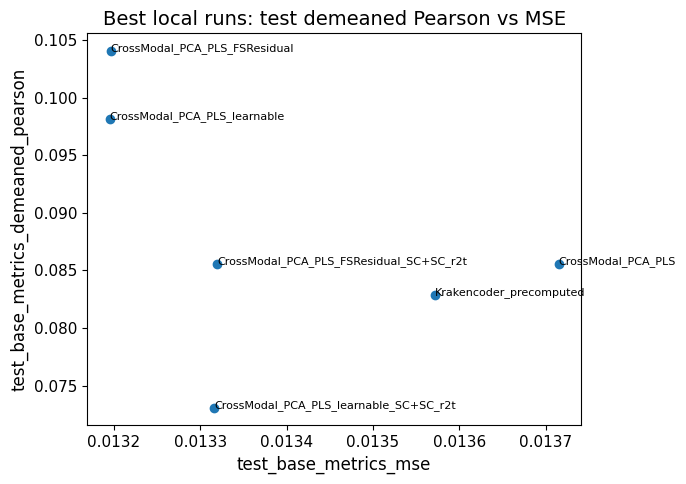

In [21]:
# Define 'to_show' as a list of run_name strings to display
to_show = [
    #"CrossModalPCA",
    "CrossModal_PCA_PLS",
    "CrossModal_PCA_PLS_learnable",
    "CrossModal_PCA_PLS_FSResidual",
    "CrossModal_PCA_PLS_learnable_SC+SC_r2t",
    "CrossModal_PCA_PLS_FSResidual_SC+SC_r2t",
    "Krakencoder_precomputed",
]

# Subset local_results_df to only include rows with run_name in to_show
to_show_df = local_results_df[local_results_df["run_name"].isin(to_show)]

plot_metric_scatter(
    to_show_df,
    x='test_base_metrics_mse',
    y='test_base_metrics_demeaned_pearson',
    label_col='run_name',
    title='Best local runs: test demeaned Pearson vs MSE')